# CLIP Model Explorer

Interactive notebook to see your trained CLIP model in action.
Change the queries, swap images, and watch the model think.

In [1]:
import sys
sys.path.insert(0, '..')

import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image
from torch.amp import autocast
from pathlib import Path

from src.model import create_model
from src.dataset import CC3MDataset

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda')
print(f'GPU: {torch.cuda.get_device_name(0)}')

GPU: NVIDIA GeForce RTX 4090


## Load Model + Data

In [2]:
# Load model and checkpoint
model, preprocess, tokenizer = create_model('ViT-B-32', device=device)

CHECKPOINT = '../checkpoints/step_020000.pt'
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Loaded step {ckpt['step']}")

# Load eval dataset
dataset = CC3MDataset(
    tsv_path='../data/cc3m/Validation_GCC-1.1.0-Validation.tsv',
    image_dir='../data/eval/images',
    transform=preprocess,
    tokenizer=tokenizer,
)
print(f'{len(dataset)} eval images loaded')

Loaded step 20000
9355 eval images loaded


In [4]:
# Helper functions

@torch.no_grad()
def encode_images(paths):
    """Encode a list of image paths into CLIP features."""
    imgs = [preprocess(Image.open(p).convert('RGB')).to(device) for p in paths]
    batch = torch.stack(imgs)
    with autocast('cuda', dtype=torch.bfloat16):
        return F.normalize(model.encode_image(batch), dim=-1)

@torch.no_grad()
def encode_texts(texts):
    """Encode a list of text strings into CLIP features."""
    tokens = tokenizer(texts).to(device)
    with autocast('cuda', dtype=torch.bfloat16):
        return F.normalize(model.encode_text(tokens), dim=-1)

def show_image(path, ax=None, title=None):
    """Display an image."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(Image.open(path).convert('RGB'))
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=9, wrap=True)

---
## 1. What does the model see in an image?

Give it an image and a bunch of text descriptions. It ranks them by similarity.
This is zero-shot classification — the model was never trained on these labels.

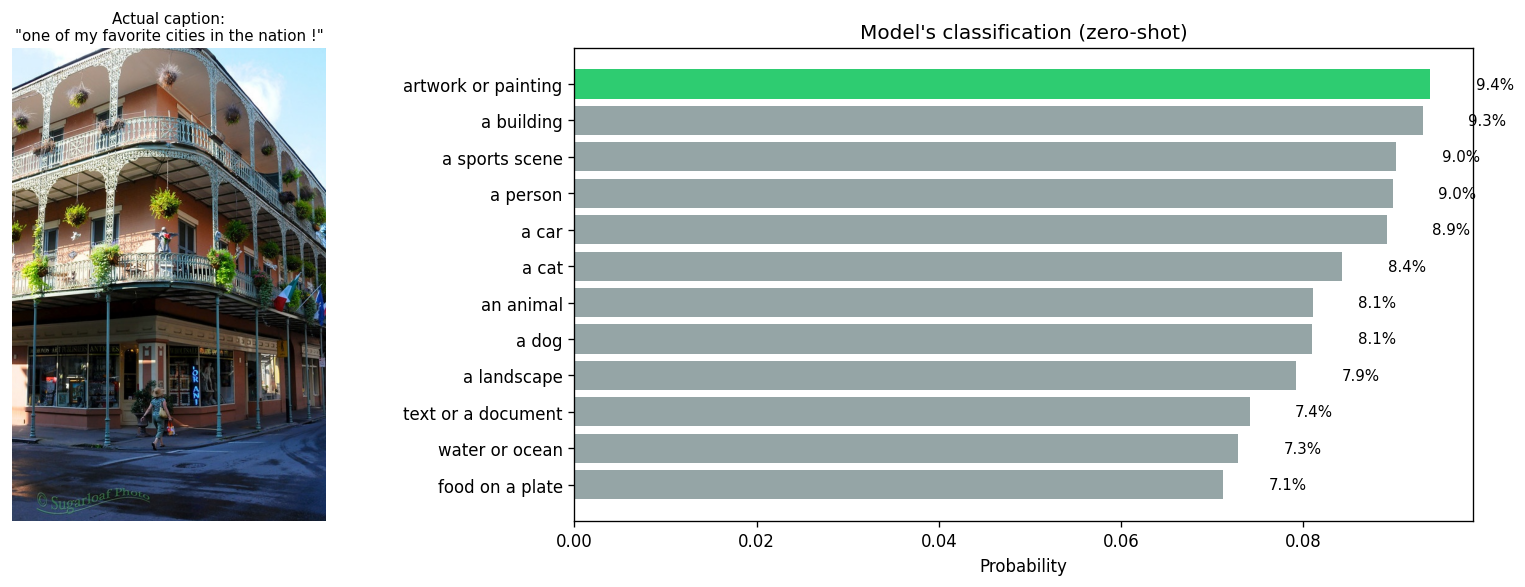

In [5]:
# Pick a random image from the eval set
idx = random.randint(0, len(dataset) - 1)
caption, img_path = dataset.samples[idx]

# These are the labels the model will choose from
# ---- TRY CHANGING THESE! ----
labels = [
    "a dog", "a cat", "a car", "food on a plate",
    "a building", "a person", "a landscape",
    "artwork or painting", "a sports scene", "an animal",
    "text or a document", "water or ocean",
]

# Encode
img_features = encode_images([img_path])
prompts = [f"a photo of {l}" for l in labels]
text_features = encode_texts(prompts)

# Compute similarities and softmax into probabilities
sims = (img_features @ text_features.t()).squeeze(0).float()
probs = sims.softmax(dim=0).cpu().numpy()

# Plot
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(14, 5),
                                      gridspec_kw={'width_ratios': [1, 1.5]})
show_image(img_path, ax=ax_img, title=f'Actual caption:\n"{caption[:80]}"')

sorted_idx = np.argsort(probs)
colors = ['#2ecc71' if i == sorted_idx[-1] else '#95a5a6' for i in range(len(labels))]
bars = ax_bar.barh([labels[i] for i in sorted_idx],
                   [probs[i] for i in sorted_idx],
                   color=[colors[i] for i in sorted_idx])
ax_bar.set_xlabel('Probability')
ax_bar.set_title('Model\'s classification (zero-shot)')
for bar, i in zip(bars, sorted_idx):
    ax_bar.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
               f'{probs[i]:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. Find me images that match this text

Type a description and the model searches through 500 images to find the best matches.

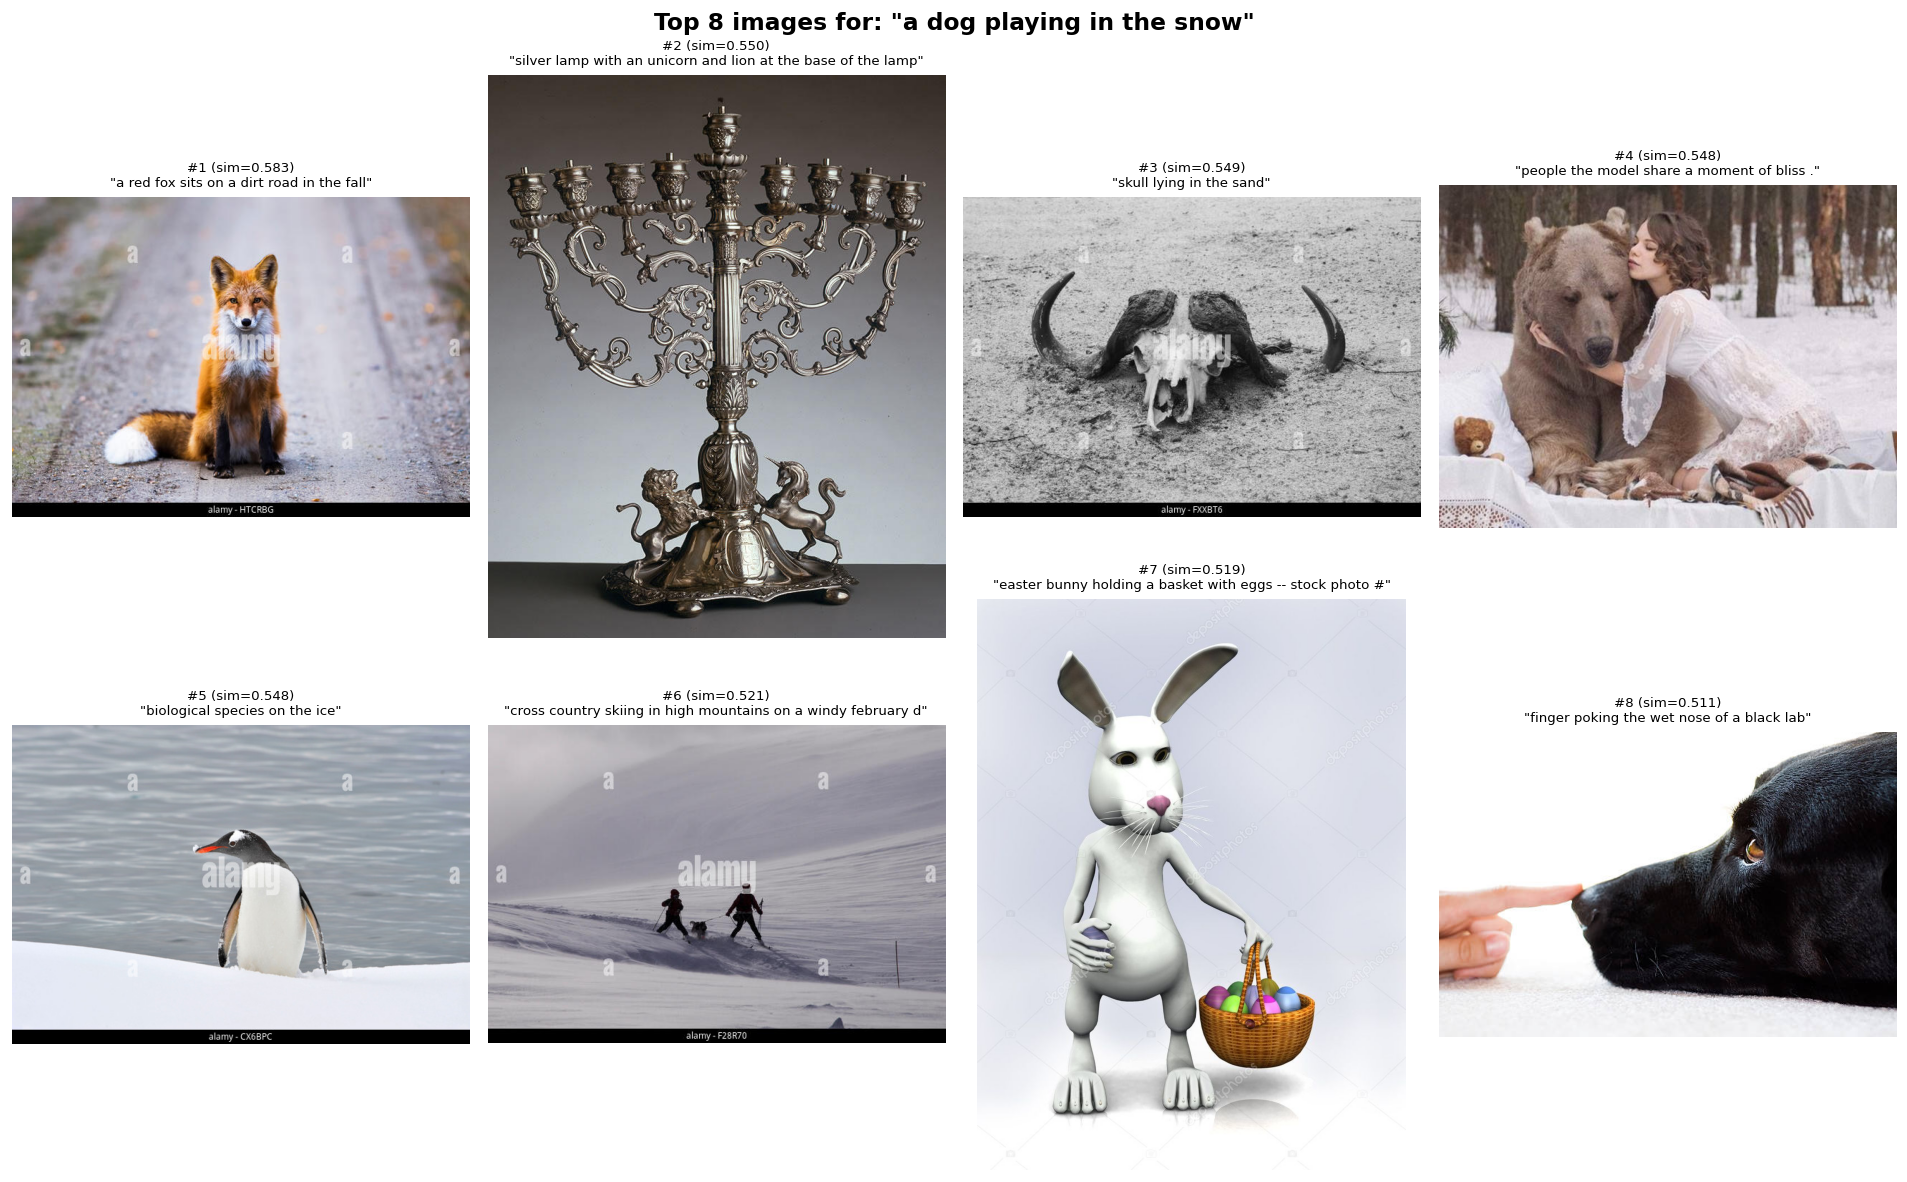

In [6]:
# ---- CHANGE THIS QUERY! ----
query = "a dog playing in the snow"

# Encode a pool of candidate images
N_POOL = 500
TOP_K = 8

random.seed(42)  # For reproducibility — change seed for different pool
pool_indices = random.sample(range(len(dataset)), min(N_POOL, len(dataset)))
pool_paths = [dataset.samples[i][1] for i in pool_indices]
pool_captions = [dataset.samples[i][0] for i in pool_indices]

# Encode in batches to avoid OOM
all_img_features = []
batch_size = 64
for i in range(0, len(pool_paths), batch_size):
    batch_paths = pool_paths[i:i+batch_size]
    valid_paths = []
    for p in batch_paths:
        try:
            Image.open(p).verify()
            valid_paths.append(p)
        except:
            continue
    if valid_paths:
        all_img_features.append(encode_images(valid_paths))

img_features = torch.cat(all_img_features, dim=0)
text_features = encode_texts([query])

sims = (text_features @ img_features.t()).squeeze(0).float()
topk_vals, topk_idx = sims.topk(TOP_K)

# Display results
cols = 4
rows = (TOP_K + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
fig.suptitle(f'Top {TOP_K} images for: "{query}"', fontsize=14, fontweight='bold')

for rank, (ax, sim, idx) in enumerate(zip(axes.flat, topk_vals, topk_idx)):
    path = pool_paths[idx.item()]
    cap = pool_captions[idx.item()]
    img = Image.open(path).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'#{rank+1} (sim={sim.item():.3f})\n"{cap[:60]}"', fontsize=8)
    ax.axis('off')

for ax in axes.flat[TOP_K:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 3. Compare any two things

How similar does the model think two texts or two images are?

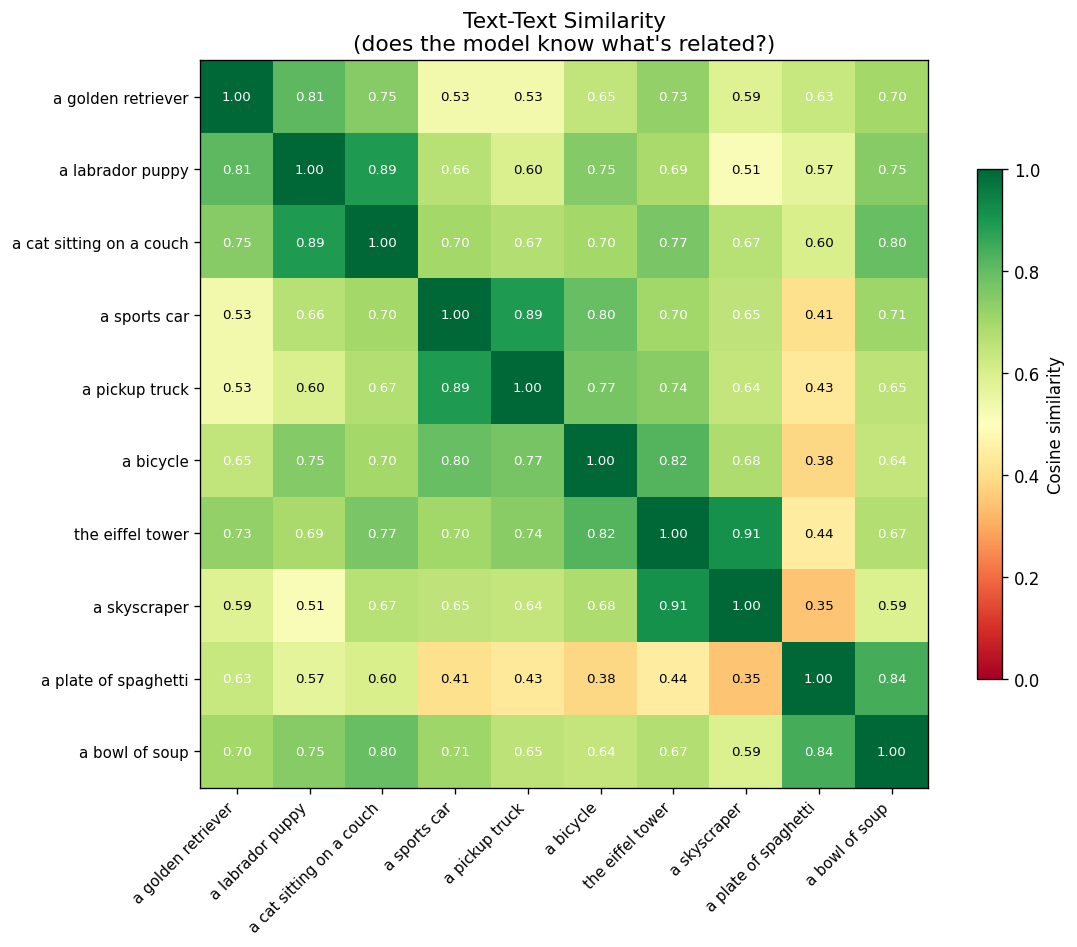

In [7]:
# ---- CHANGE THESE! ----
texts = [
    "a golden retriever",
    "a labrador puppy",
    "a cat sitting on a couch",
    "a sports car",
    "a pickup truck",
    "a bicycle",
    "the eiffel tower",
    "a skyscraper",
    "a plate of spaghetti",
    "a bowl of soup",
]

features = encode_texts(texts)
sim_matrix = (features @ features.t()).float().cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)

for i in range(len(texts)):
    for j in range(len(texts)):
        color = 'white' if sim_matrix[i, j] > 0.6 else 'black'
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color=color)

ax.set_xticks(range(len(texts)))
ax.set_xticklabels(texts, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(texts)))
ax.set_yticklabels(texts, fontsize=9)
fig.colorbar(im, shrink=0.7, label='Cosine similarity')
ax.set_title('Text-Text Similarity\n(does the model know what\'s related?)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Image-Caption matching

See the full NxN similarity matrix — the model's "brain" deciding which image goes with which text. Green diagonal = correct matches.

/tmp/ipykernel_278111/2845915763.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


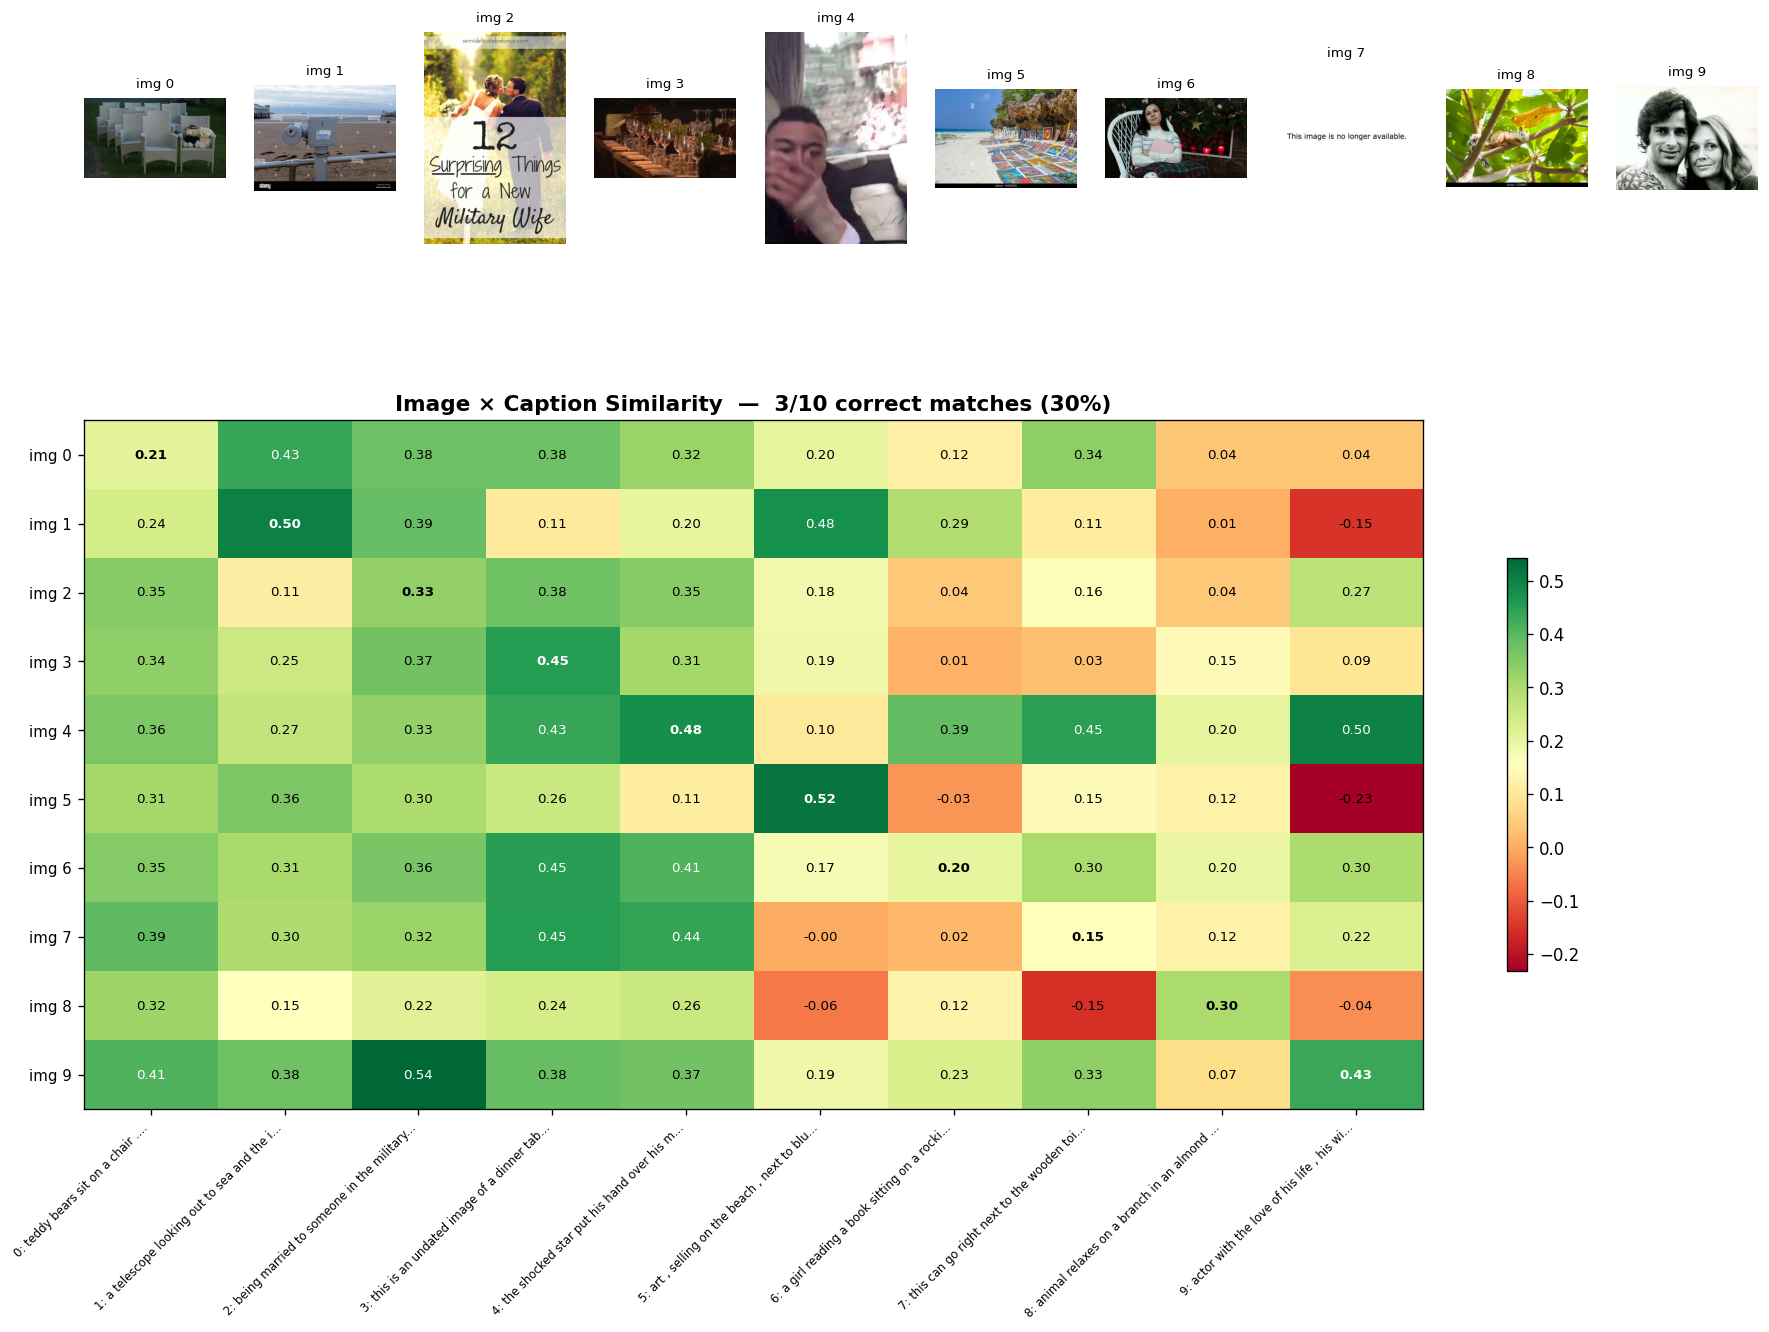

In [8]:
N = 10  # Number of samples
random.seed(99)  # Change for different samples
indices = random.sample(range(len(dataset)), N)

images, captions, paths = [], [], []
for idx in indices:
    try:
        img_tensor, _ = dataset[idx]
        images.append(img_tensor)
        captions.append(dataset.samples[idx][0][:40])
        paths.append(dataset.samples[idx][1])
    except:
        continue

img_batch = torch.stack(images).to(device)
txt_tokens = tokenizer(captions).to(device)

with torch.no_grad(), autocast('cuda', dtype=torch.bfloat16):
    img_feat = F.normalize(model.encode_image(img_batch), dim=-1)
    txt_feat = F.normalize(model.encode_text(txt_tokens), dim=-1)

sim = (img_feat @ txt_feat.t()).float().cpu().numpy()
n = len(images)

# Big visualization
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, n, height_ratios=[1, 2.5], hspace=0.3)

# Thumbnails
for i in range(n):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(Image.open(paths[i]).convert('RGB'))
    ax.axis('off')
    ax.set_title(f'img {i}', fontsize=8)

# Heatmap
ax = fig.add_subplot(gs[1, :])
im = ax.imshow(sim, cmap='RdYlGn', aspect='auto')
for i in range(n):
    for j in range(n):
        weight = 'bold' if i == j else 'normal'
        color = 'white' if abs(sim[i,j]) > 0.4 else 'black'
        ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color=color, fontweight=weight)

ax.set_xticks(range(n))
ax.set_xticklabels([f'{i}: {c}...' for i, c in enumerate(captions)],
                    rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(n))
ax.set_yticklabels([f'img {i}' for i in range(n)], fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.6)

correct = sum(sim[i].argmax() == i for i in range(n))
ax.set_title(f'Image × Caption Similarity  —  {correct}/{n} correct matches ({100*correct/n:.0f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Embedding space (UMAP)

Where do images and texts live in the model's 512-dimensional space?
Matching pairs should be near each other.

Running UMAP on 600 embeddings (300 images + 300 texts)...


/home/adelisle/dev/clip/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


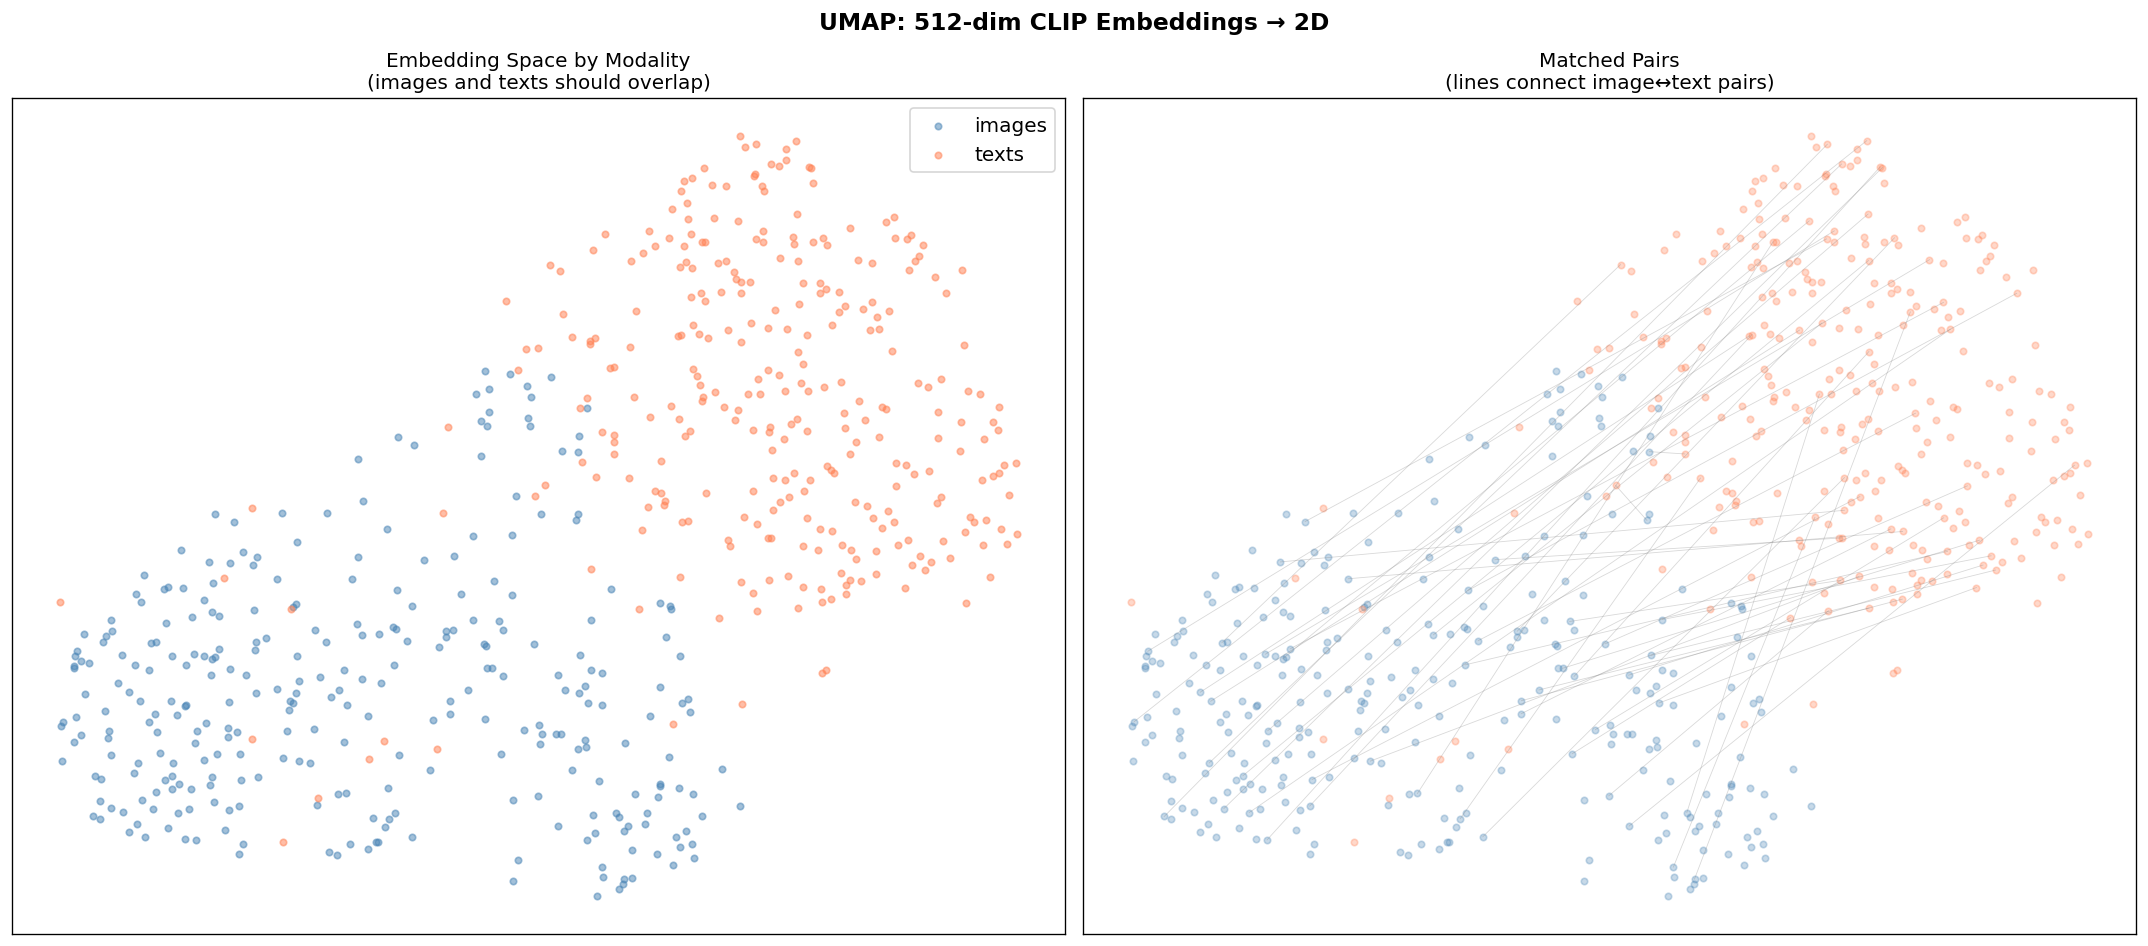

In [9]:
import umap

N_SAMPLES = 300
random.seed(42)
indices = random.sample(range(len(dataset)), min(N_SAMPLES, len(dataset)))

all_img, all_txt = [], []
batch_size = 64

for start in range(0, len(indices), batch_size):
    batch_idx = indices[start:start+batch_size]
    imgs, txts = [], []
    for idx in batch_idx:
        try:
            img_tensor, txt_tensor = dataset[idx]
            imgs.append(img_tensor)
            txts.append(txt_tensor)
        except:
            continue
    if imgs:
        img_batch = torch.stack(imgs).to(device)
        txt_batch = torch.stack(txts).to(device)
        with torch.no_grad(), autocast('cuda', dtype=torch.bfloat16):
            all_img.append(F.normalize(model.encode_image(img_batch), dim=-1).cpu())
            all_txt.append(F.normalize(model.encode_text(txt_batch), dim=-1).cpu())

img_feat = torch.cat(all_img, dim=0).float().numpy()
txt_feat = torch.cat(all_txt, dim=0).float().numpy()
n = img_feat.shape[0]

combined = np.concatenate([img_feat, txt_feat], axis=0)
print(f'Running UMAP on {combined.shape[0]} embeddings ({n} images + {n} texts)...')

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
embedding = reducer.fit_transform(combined)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: colored by modality
ax = axes[0]
ax.scatter(embedding[:n, 0], embedding[:n, 1], c='steelblue', alpha=0.5, s=15, label='images')
ax.scatter(embedding[n:, 0], embedding[n:, 1], c='coral', alpha=0.5, s=15, label='texts')
ax.legend(fontsize=12)
ax.set_title('Embedding Space by Modality\n(images and texts should overlap)', fontsize=12)
ax.set_xticks([])
ax.set_yticks([])

# Right: show matched pairs with lines
ax = axes[1]
ax.scatter(embedding[:n, 0], embedding[:n, 1], c='steelblue', alpha=0.3, s=15)
ax.scatter(embedding[n:, 0], embedding[n:, 1], c='coral', alpha=0.3, s=15)

# Draw lines between matched pairs (subsample for clarity)
for i in range(0, n, max(1, n // 50)):
    ax.plot([embedding[i, 0], embedding[n+i, 0]],
            [embedding[i, 1], embedding[n+i, 1]],
            c='gray', alpha=0.3, linewidth=0.5)

ax.set_title('Matched Pairs\n(lines connect image↔text pairs)', fontsize=12)
ax.set_xticks([])
ax.set_yticks([])

fig.suptitle('UMAP: 512-dim CLIP Embeddings → 2D', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Your own image

Drop any image file in the repo and point to it here.

In [ ]:
# ---- PUT YOUR OWN IMAGE PATH HERE ----
# my_image = '../my_photo.jpg'
#
# For now, use a random eval image:
my_image = str(dataset.samples[random.randint(0, len(dataset)-1)][1])

# ---- AND YOUR OWN LABELS ----
my_labels = [
    "a dog", "a cat", "a bird", "a fish",
    "a car", "a truck", "a bicycle",
    "food", "a person", "a building",
    "a tree", "water", "the sky",
    "a painting", "a screenshot", "a diagram",
]

img_features = encode_images([my_image])
prompts = [f"a photo of {l}" for l in my_labels]
text_features = encode_texts(prompts)
sims = (img_features @ text_features.t()).squeeze(0).float()
probs = sims.softmax(dim=0).cpu().numpy()

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(14, 6),
                                      gridspec_kw={'width_ratios': [1, 1.5]})
ax_img.imshow(Image.open(my_image).convert('RGB'))
ax_img.axis('off')
ax_img.set_title('Your image', fontsize=12)

sorted_idx = np.argsort(probs)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(my_labels)))
ax_bar.barh([my_labels[i] for i in sorted_idx],
            [probs[i] for i in sorted_idx],
            color=colors)
ax_bar.set_xlabel('Probability')
ax_bar.set_title('What does the model see?', fontsize=12)
plt.tight_layout()
plt.show()